# 02 – Data Cleaning
**Bluestock Fintech Mutual Fund Analytics Platform**

This notebook runs the full ETL pipeline: validates, cleans, transforms all datasets and saves processed files.

In [1]:
import sys, os
from pathlib import Path
BASE = Path("..").resolve()
sys.path.insert(0, str(BASE / "scripts"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Run ETL Pipeline

In [2]:
from etl_pipeline import run
cleaned = run()
print("\nETL Pipeline Complete!")

2026-06-02 19:23:20,413 | INFO     | ============================================================
2026-06-02 19:23:20,414 | INFO     | Bluestock MF Capstone - ETL Pipeline START
2026-06-02 19:23:20,415 | INFO     | ============================================================
2026-06-02 19:23:20,420 | INFO     | Loaded fund_master: 40 rows × 15 cols
2026-06-02 19:23:20,438 | INFO     | Loaded nav_history: 46,000 rows × 3 cols
2026-06-02 19:23:20,441 | INFO     | Loaded aum_by_fund_house: 90 rows × 5 cols
2026-06-02 19:23:20,444 | INFO     | Loaded monthly_sip_inflows: 48 rows × 6 cols
2026-06-02 19:23:20,446 | INFO     | Loaded category_inflows: 144 rows × 3 cols
2026-06-02 19:23:20,449 | INFO     | Loaded industry_folio_count: 21 rows × 6 cols
2026-06-02 19:23:20,452 | INFO     | Loaded scheme_performance: 40 rows × 19 cols
2026-06-02 19:23:20,505 | INFO     | Loaded investor_transactions: 32,778 rows × 13 cols
2026-06-02 19:23:20,508 | INFO     | Loaded portfolio_holdings: 322 rows × 


ETL Pipeline Complete!


## Validation – Before vs After

In [3]:
RAW  = BASE / "data" / "raw"
PROC = BASE / "data" / "processed"

comparison = []
for name, df_clean in cleaned.items():
    raw_file = [f for f in os.listdir(RAW) if name.replace("_"," ") in f.replace("_"," ") or name in f]
    comparison.append({
        "table": name,
        "clean_rows": len(df_clean),
        "clean_cols": df_clean.shape[1],
        "null_after":  df_clean.isnull().sum().sum(),
        "dup_after":   df_clean.duplicated().sum(),
    })

df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))

                table  clean_rows  clean_cols  null_after  dup_after
          fund_master          40          15           0          0
          nav_history       46000           4          40          0
    aum_by_fund_house          90           5           0          0
  monthly_sip_inflows          48           6           0          0
     category_inflows         144           3           0          0
 industry_folio_count          21           6           0          0
   scheme_performance          40          19           0          0
investor_transactions       32778          13           0          0
   portfolio_holdings         322           8           0          0
    benchmark_indices        8050           4           7          0


## Missing Value Heatmap (Cleaned Data)

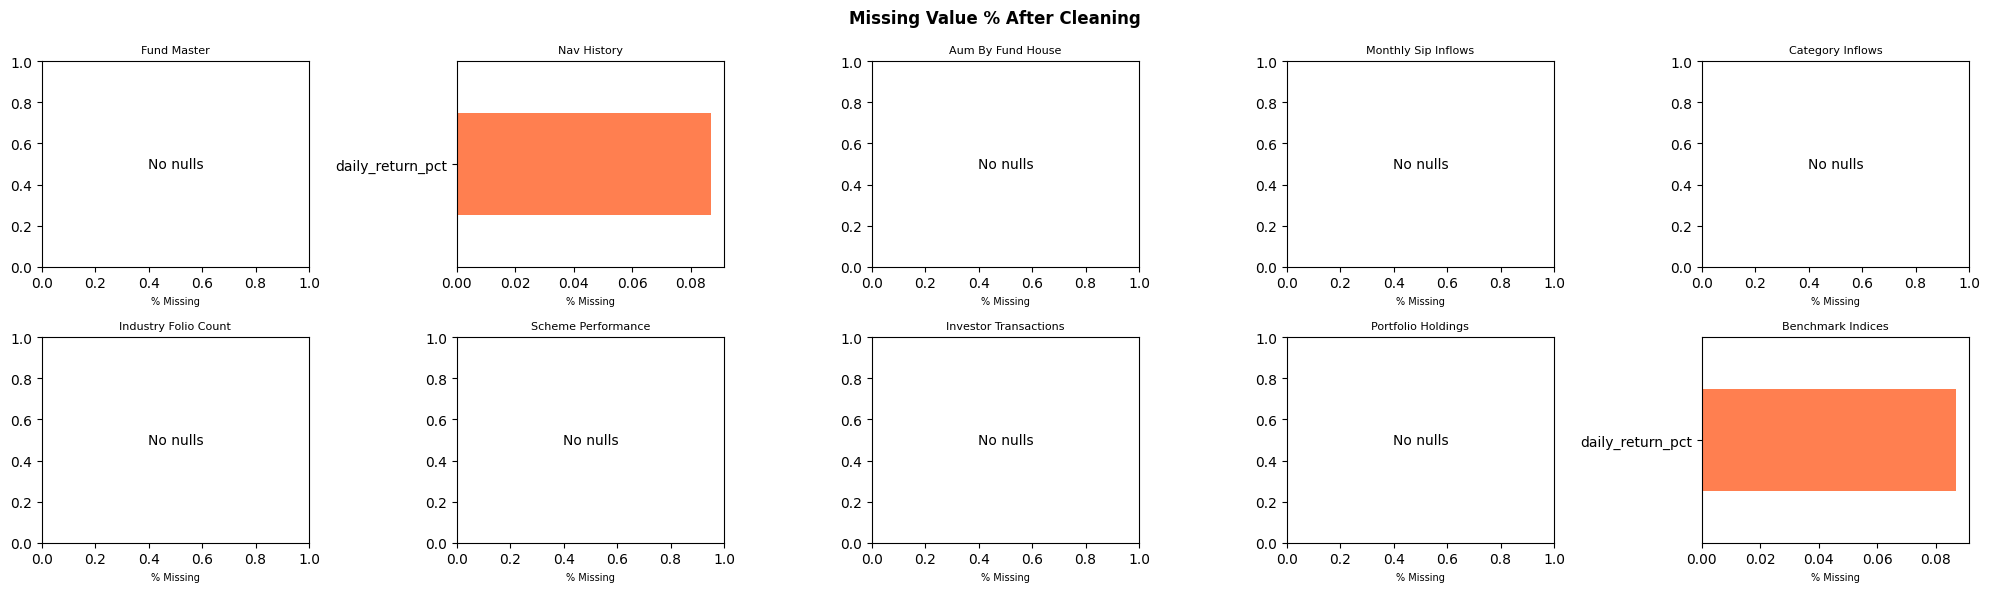

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()
for ax, (name, df) in zip(axes, cleaned.items()):
    null_pct = df.isnull().mean() * 100
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        ax.text(0.5, 0.5, "No nulls", ha="center", va="center", transform=ax.transAxes)
    else:
        null_pct.plot(kind="barh", ax=ax, color="coral")
    ax.set_title(name.replace("_"," ").title(), fontsize=8)
    ax.set_xlabel("% Missing", fontsize=7)
plt.suptitle("Missing Value % After Cleaning", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE / "reports" / "missing_values_post_clean.png", dpi=150)
plt.show()

## Data Type Verification

In [5]:
for name in ["nav_history", "investor_transactions", "benchmark_indices"]:
    df = cleaned[name]
    print(f"\n{name}:")
    print(df.dtypes.to_string())
    print(f"  Rows: {len(df):,}")


nav_history:
amfi_code             int64
date                 object
nav                 float64
daily_return_pct    float64
  Rows: 46,000

investor_transactions:
investor_id            object
transaction_date       object
amfi_code               int64
transaction_type       object
amount_inr              int64
state                  object
city                   object
city_tier              object
age_group              object
gender                 object
annual_income_lakh    float64
payment_mode           object
kyc_status             object
  Rows: 32,778

benchmark_indices:
date                 object
index_name           object
close_value         float64
daily_return_pct    float64
  Rows: 8,050


In [7]:
print("\n Data Cleaning Notebook Complete")
print("All cleaned files saved in data/processed/")


 Data Cleaning Notebook Complete
All cleaned files saved in data/processed/
